In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import gc
import time

import psutil
from datetime import datetime

import anndata as an
import scanpy as sc

sc.settings.verbosity = 3

In [2]:
dpath = "/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/"

file_list = glob.glob(f"{dpath}hsc_a*/*.h5ad")
file_list

['/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_aux/lymphoid_cells.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/hsc_and_progenitors.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/fibroblasts.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/mesenchymal_cells.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/myeloid_cells.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/innate_lymphoid_cells.h5ad',
 '/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/endothelial_cells.h5ad']

In [3]:
overall_start_time = time.time() # Start overall timer

obs_list = []

for fpath in file_list:
    loop_start_time = time.time() # Start timer for this file iteration

    basename = os.path.basename(fpath).replace(".h5ad", "")
    print(f"Working {basename}...")

    read_start_time = time.time()
    adata = sc.read_h5ad(fpath, backed='r')
    obs = adata.obs.copy()
    read_end_time = time.time()
    print(f"\tRead+Copy took: {read_end_time - read_start_time:.2f} seconds")

    obs['basename'] = " ".join(basename.split("_"))
    print(f"\t{obs.shape=}")
    obs_list.append(obs)

    loop_end_time = time.time() # End timer for this file iteration
    print(f"\tIteration for {basename} took: {loop_end_time - loop_start_time:.2f} seconds")
    print("-" * 20) # Separator


print("Concatenating DataFrames...")
concat_start_time = time.time()
df = pd.concat(obs_list)
concat_end_time = time.time()
print(f"Concatenation took: {concat_end_time - concat_start_time:.2f} seconds")

# clean up
del adata
del obs_list
gc.collect()

print(f"{df.shape=}")

overall_end_time = time.time() # End overall timer
print(f"\nTotal script execution time: {overall_end_time - overall_start_time:.2f} seconds")

Working lymphoid_cells...
	Read+Copy took: 8.57 seconds
	obs.shape=(3761959, 29)
	Iteration for lymphoid_cells took: 8.58 seconds
--------------------
Working hsc_and_progenitors...
	Read+Copy took: 0.26 seconds
	obs.shape=(66394, 29)
	Iteration for hsc_and_progenitors took: 0.26 seconds
--------------------
Working fibroblasts...
	Read+Copy took: 2.50 seconds
	obs.shape=(1277902, 29)
	Iteration for fibroblasts took: 2.51 seconds
--------------------
Working mesenchymal_cells...
	Read+Copy took: 1.23 seconds
	obs.shape=(650601, 29)
	Iteration for mesenchymal_cells took: 1.23 seconds
--------------------
Working myeloid_cells...
	Read+Copy took: 2.22 seconds
	obs.shape=(1147059, 29)
	Iteration for myeloid_cells took: 2.22 seconds
--------------------
Working innate_lymphoid_cells...
	Read+Copy took: 0.18 seconds
	obs.shape=(15277, 29)
	Iteration for innate_lymphoid_cells took: 0.18 seconds
--------------------
Working endothelial_cells...
	Read+Copy took: 2.02 seconds
	obs.shape=(104339

# Load in cell type annotations

In [4]:
fpath = "../resources/cell_type_annotation.csv"
cdf = pd.read_csv(fpath)

type_map = dict(zip(cdf['cell_id'].values, cdf['cell_type'].values))
level_1_map = dict(zip(cdf['cell_id'].values, cdf['level_1'].values))

df['cell_type_annotation'] = df['cell_type_ontology_term_id'].map(type_map)
df['level_1_annotation'] = df['cell_type_ontology_term_id'].map(level_1_map)

df.head()

,soma_joinid,dataset_id,assay,assay_ontology_term_id,cell_type,cell_type_ontology_term_id,development_stage,development_stage_ontology_term_id,disease,disease_ontology_term_id,...,tissue_general,tissue_general_ontology_term_id,raw_sum,nnz,raw_mean_nnz,raw_variance_nnz,n_measured_vars,basename,cell_type_annotation,level_1_annotation
0,4308,a5d95a42-0137-496f-8a60-101e17f263c8,Smart-seq2,EFO:0008931,naive B cell,CL:0000788,26-year-old human stage,HsapDv:0000120,normal,PATO:0000461,...,blood,UBERON:0000178,17691.0,1199,14.754796,624.620960,19149,lymphoid cells,naive B cell,leukocyte
1,4309,a5d95a42-0137-496f-8a60-101e17f263c8,Smart-seq2,EFO:0008931,naive B cell,CL:0000788,26-year-old human stage,HsapDv:0000120,normal,PATO:0000461,...,blood,UBERON:0000178,13612.0,841,16.185493,1394.944123,19149,lymphoid cells,naive B cell,leukocyte
2,4310,a5d95a42-0137-496f-8a60-101e17f263c8,Smart-seq2,EFO:0008931,naive B cell,CL:0000788,26-year-old human stage,HsapDv:0000120,normal,PATO:0000461,...,blood,UBERON:0000178,126774.0,1683,75.326203,42215.146798,19149,lymphoid cells,naive B cell,leukocyte
3,4311,a5d95a42-0137-496f-8a60-101e17f263c8,Smart-seq2,EFO:0008931,naive B cell,CL:0000788,26-year-old human stage,HsapDv:0000120,normal,PATO:0000461,...,blood,UBERON:0000178,14370.0,371,38.733154,4639.990763,19149,lymphoid cells,naive B cell,leukocyte
4,4312,a5d95a42-0137-496f-8a60-101e17f263c8,Smart-seq2,EFO:0008931,naive B cell,CL:0000788,26-year-old human stage,HsapDv:0000120,normal,PATO:0000461,...,blood,UBERON:0000178,13738.0,507,27.096647,3874.079574,19149,lymphoid cells,naive B cell,leukocyte


In [31]:
n_cells = df.shape[0]
n_cell_types = df['cell_type'].nunique()
n_tissues = df['tissue_general'].nunique()
n_datasets = df['dataset_id'].nunique()
n_assays = df['assay'].nunique()

summary = pd.DataFrame({
    "Statistic": [
        "Total Cells",
        "Unique Cell Types",
        "Unique Tissues",
        "Unique Datasets",
        "Unique Assays"
    ],
    "Count": [
        n_cells,
        n_cell_types,
        n_tissues,
        n_datasets,
        n_assays
    ]
})

print(summary.to_latex(index=False))

\begin{tabular}{lr}
\toprule
Statistic & Count \\
\midrule
Total Cells & 7962590 \\
Unique Cell Types & 185 \\
Unique Tissues & 51 \\
Unique Datasets & 270 \\
Unique Assays & 21 \\
\bottomrule
\end{tabular}



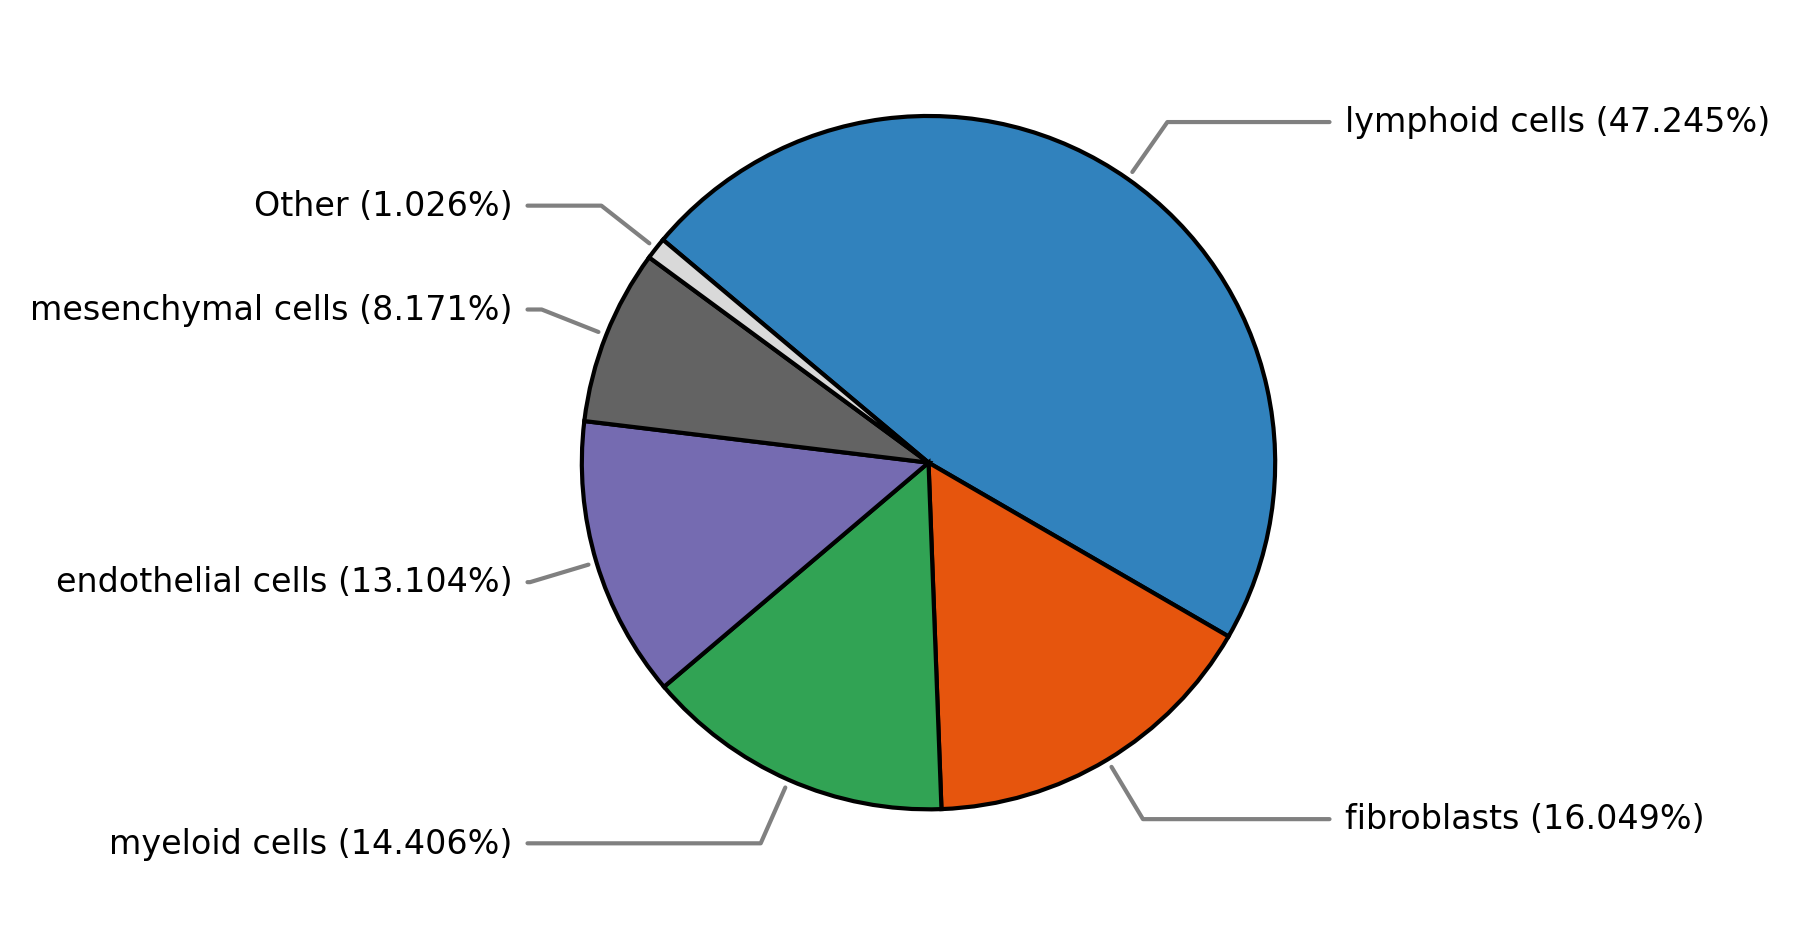

In [27]:
# Compute value counts
value_counts = df['basename'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.tab20c(np.linspace(0, 1, len(value_counts_grouped)))


# Pie chart without labels
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()


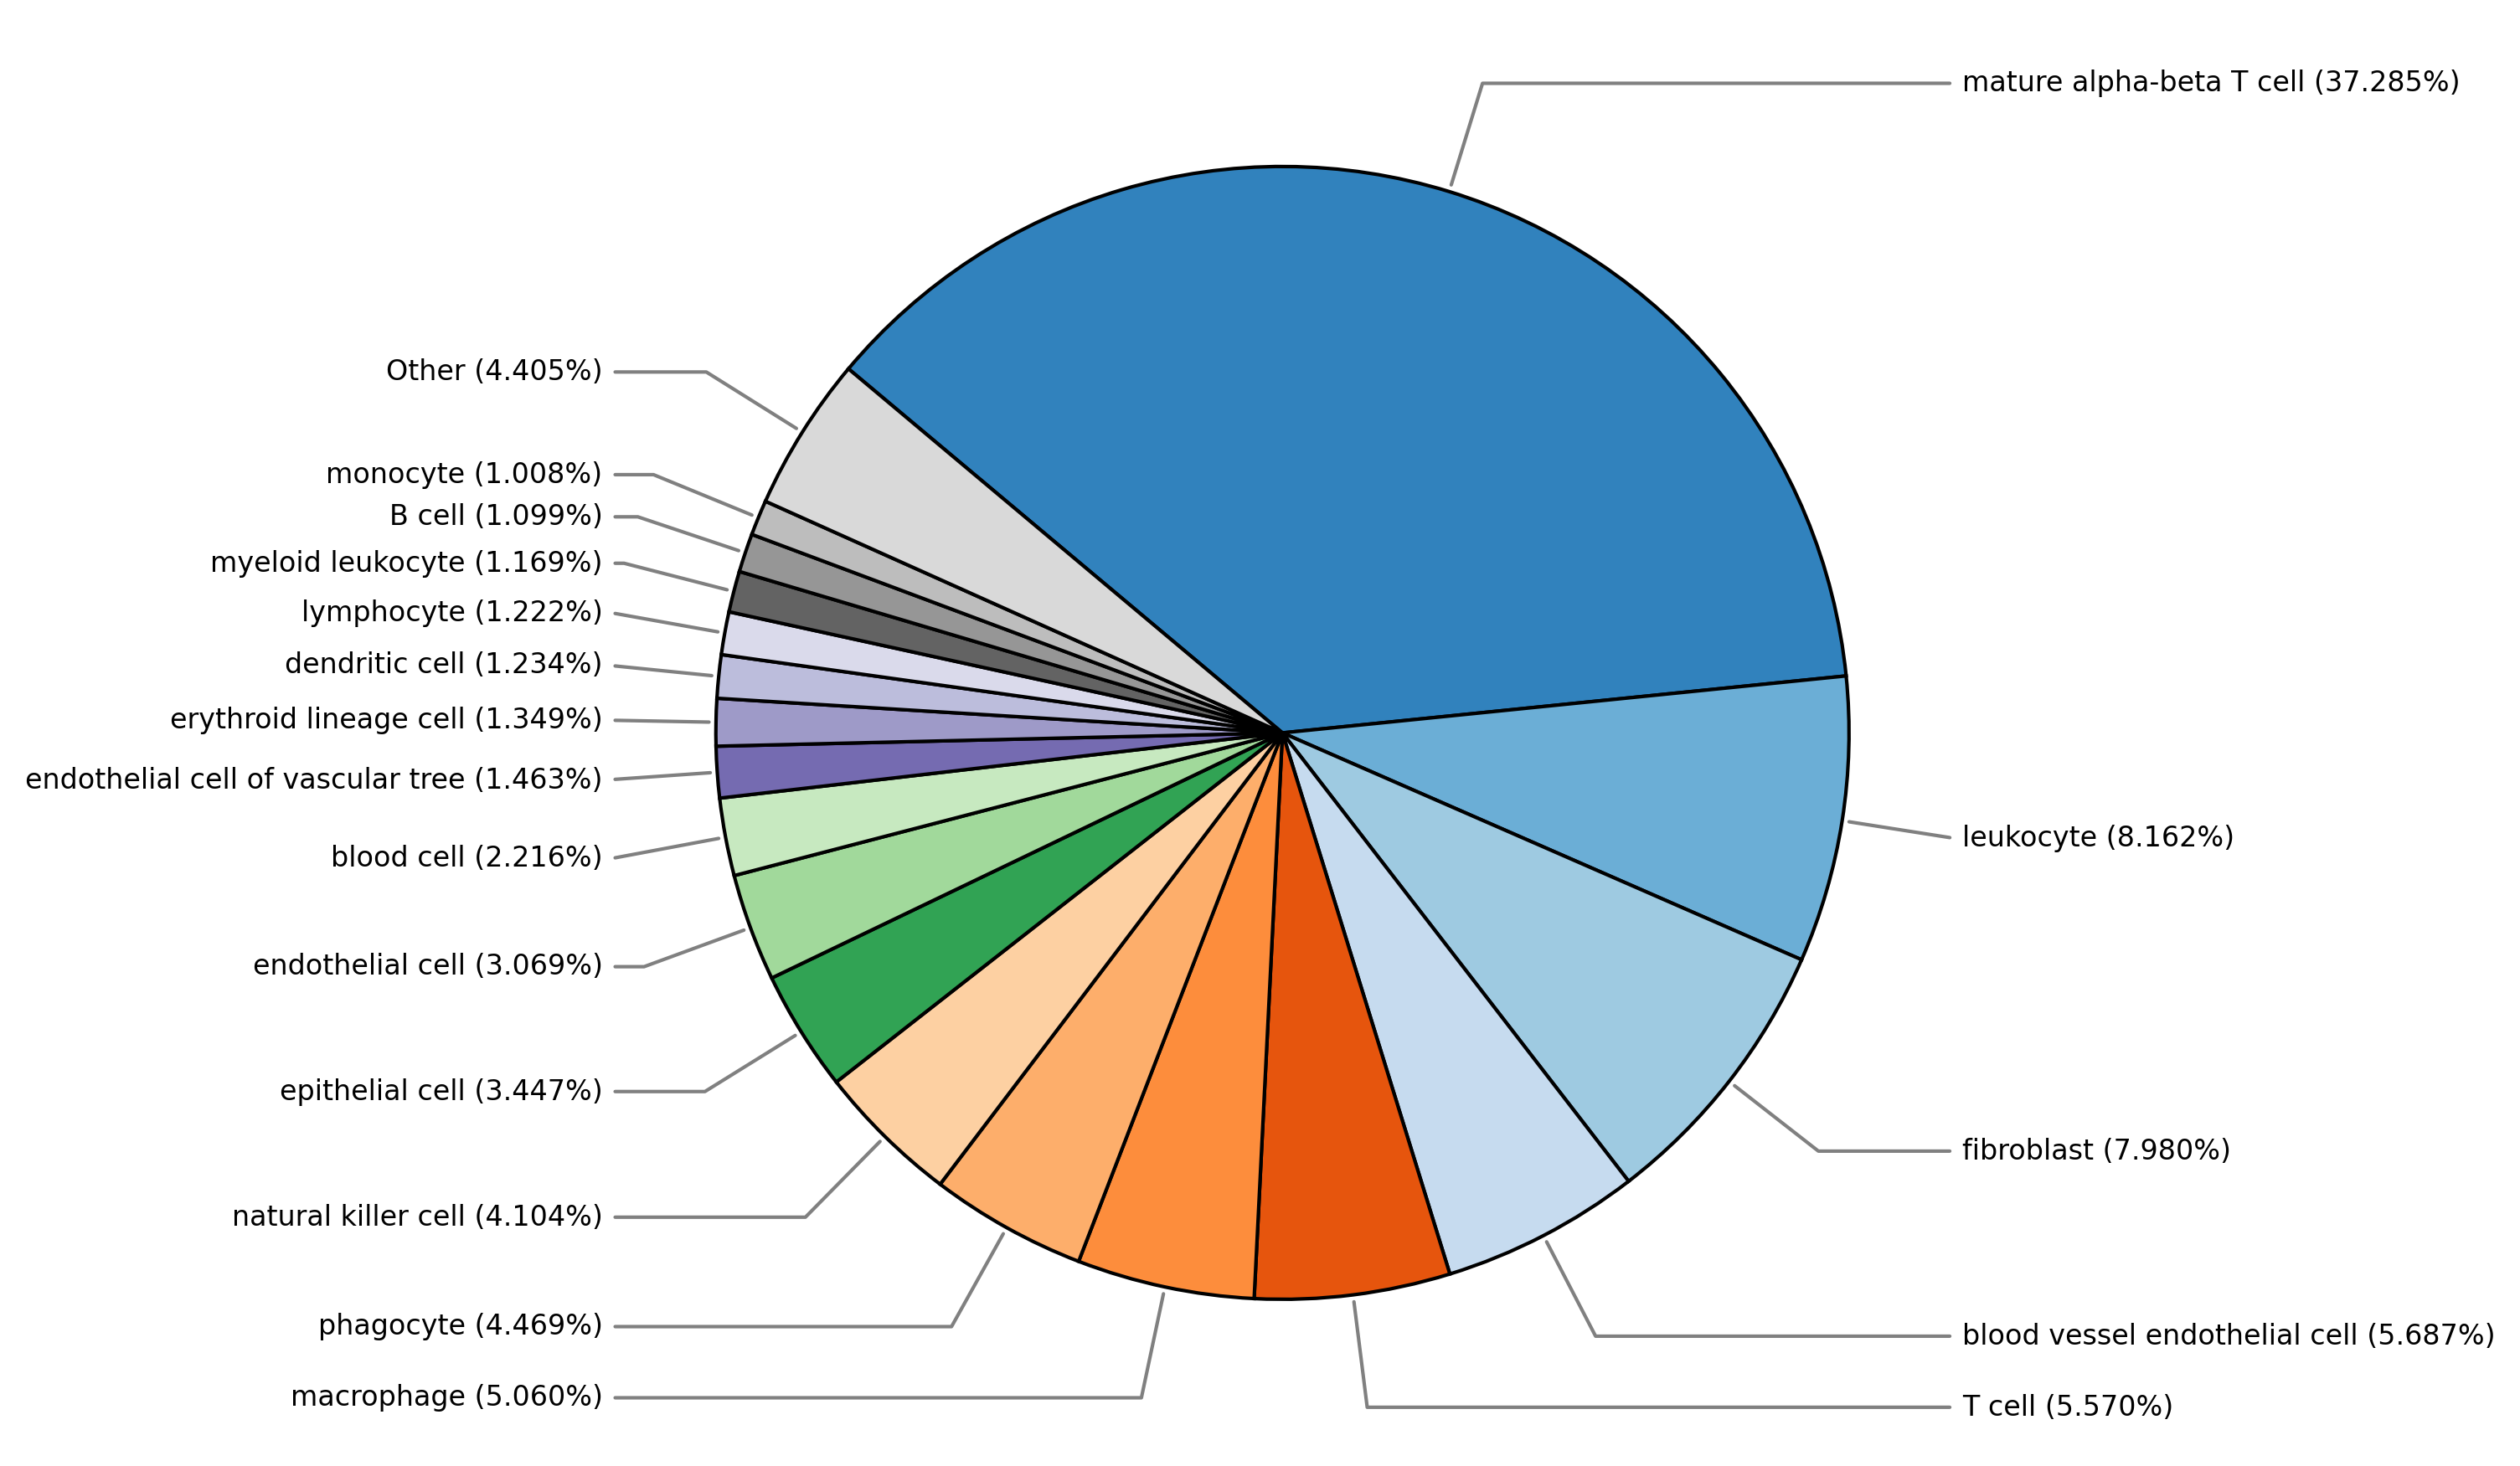

In [32]:
# Compute value counts
value_counts = df['level_1_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.tab20c(np.linspace(0, 1, len(value_counts_grouped)))

size = 10

# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Summary of HSC Types

In [39]:
query = 'hsc and progenitors'

print(f"{query}")
pdf = df[df['basename'] == query]
print(f"\tn cells {pdf.shape[0]}")
print(f"\tn cell types {pdf['cell_type_annotation'].nunique()}")
print(f"\tn cell types {pdf['level_1_annotation'].nunique()}")

hsc and progenitors
	n cells 66394
	n cell types 11
	n cell types 6


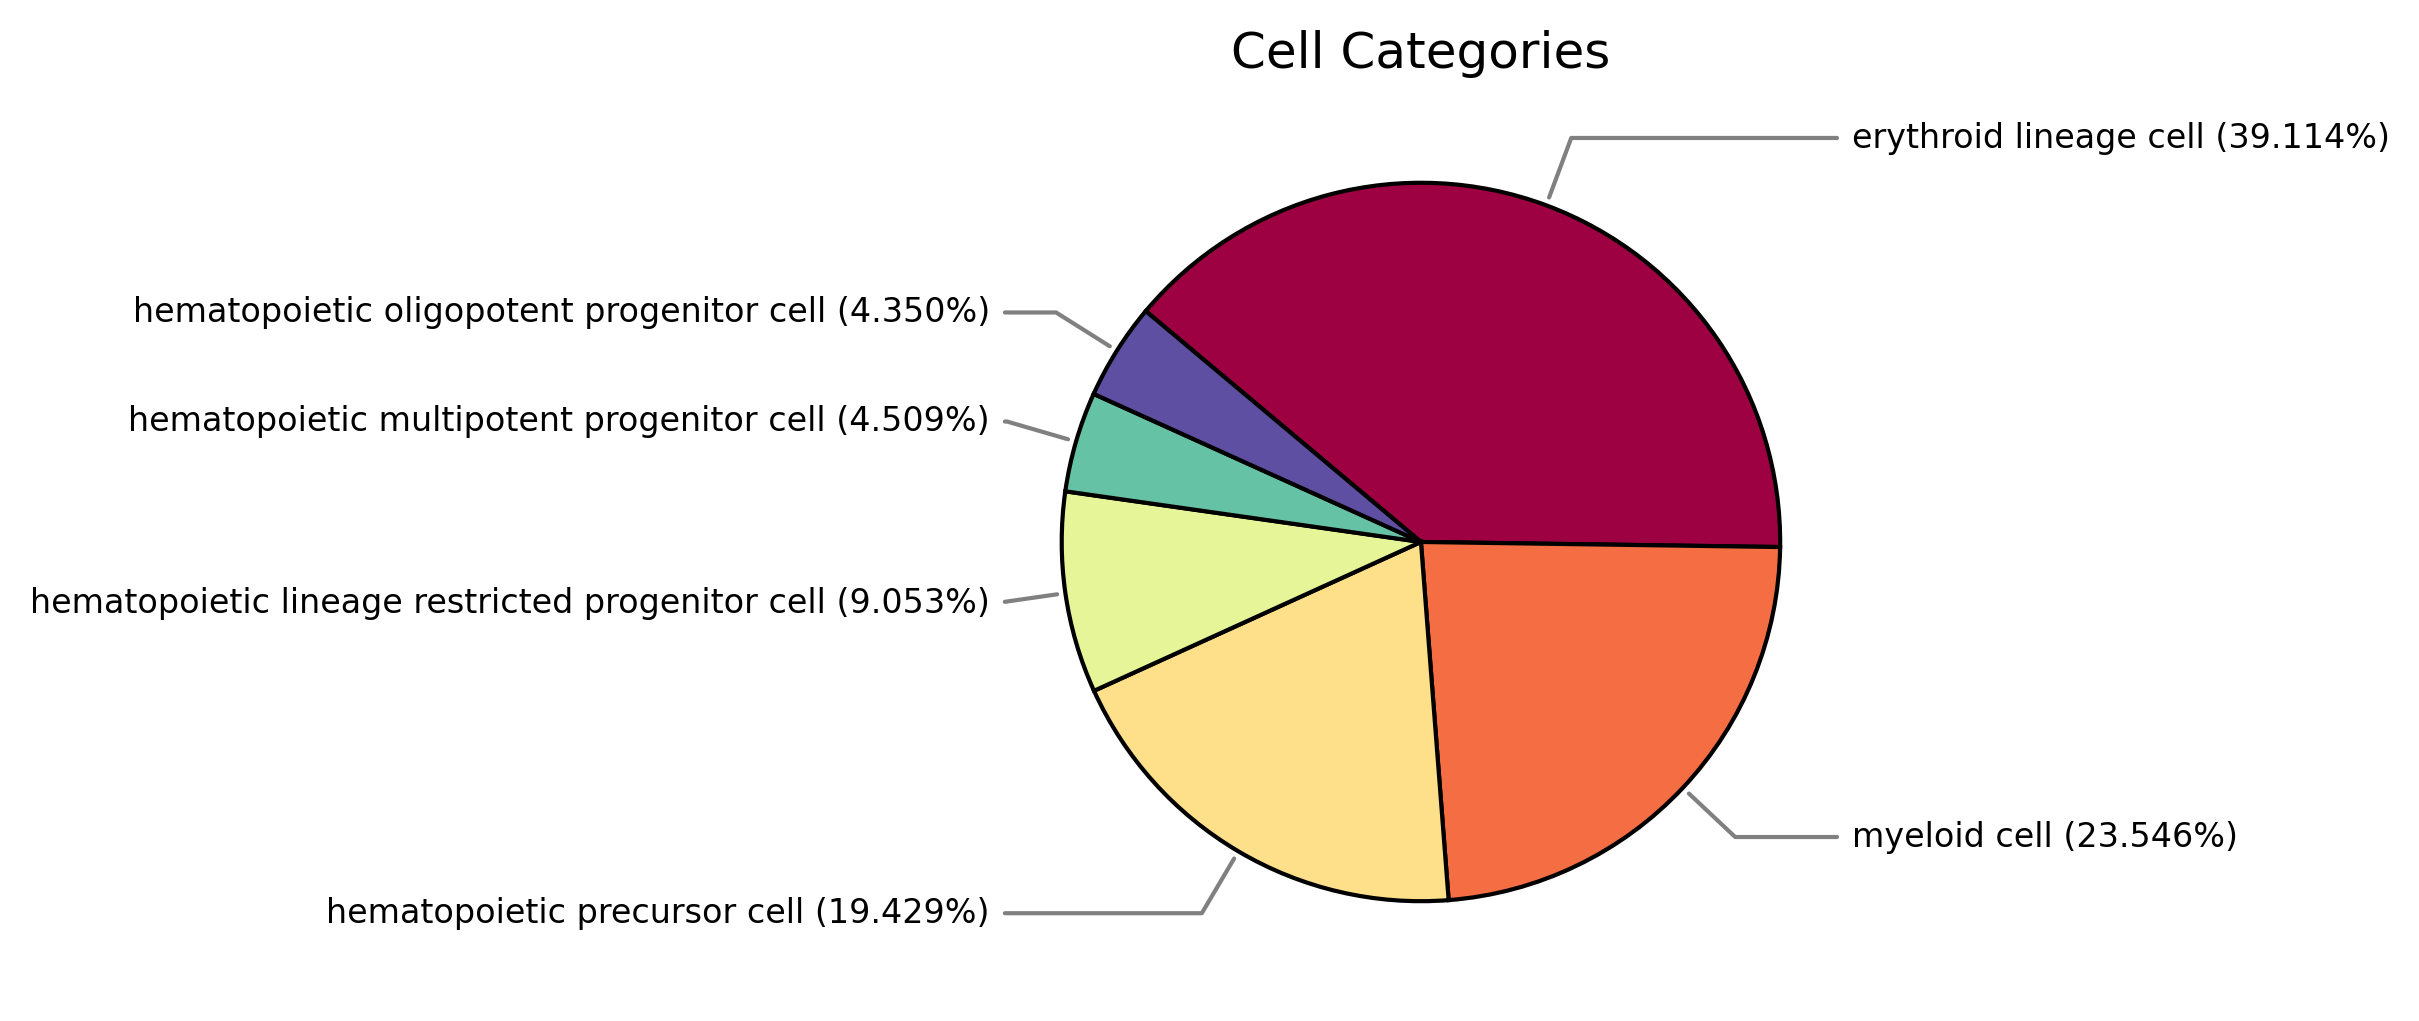

In [51]:
# Compute value counts
value_counts = pdf['level_1_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.Spectral(np.linspace(0, 1, len(value_counts_grouped)))

size = 8
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_title('Cell Categories')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

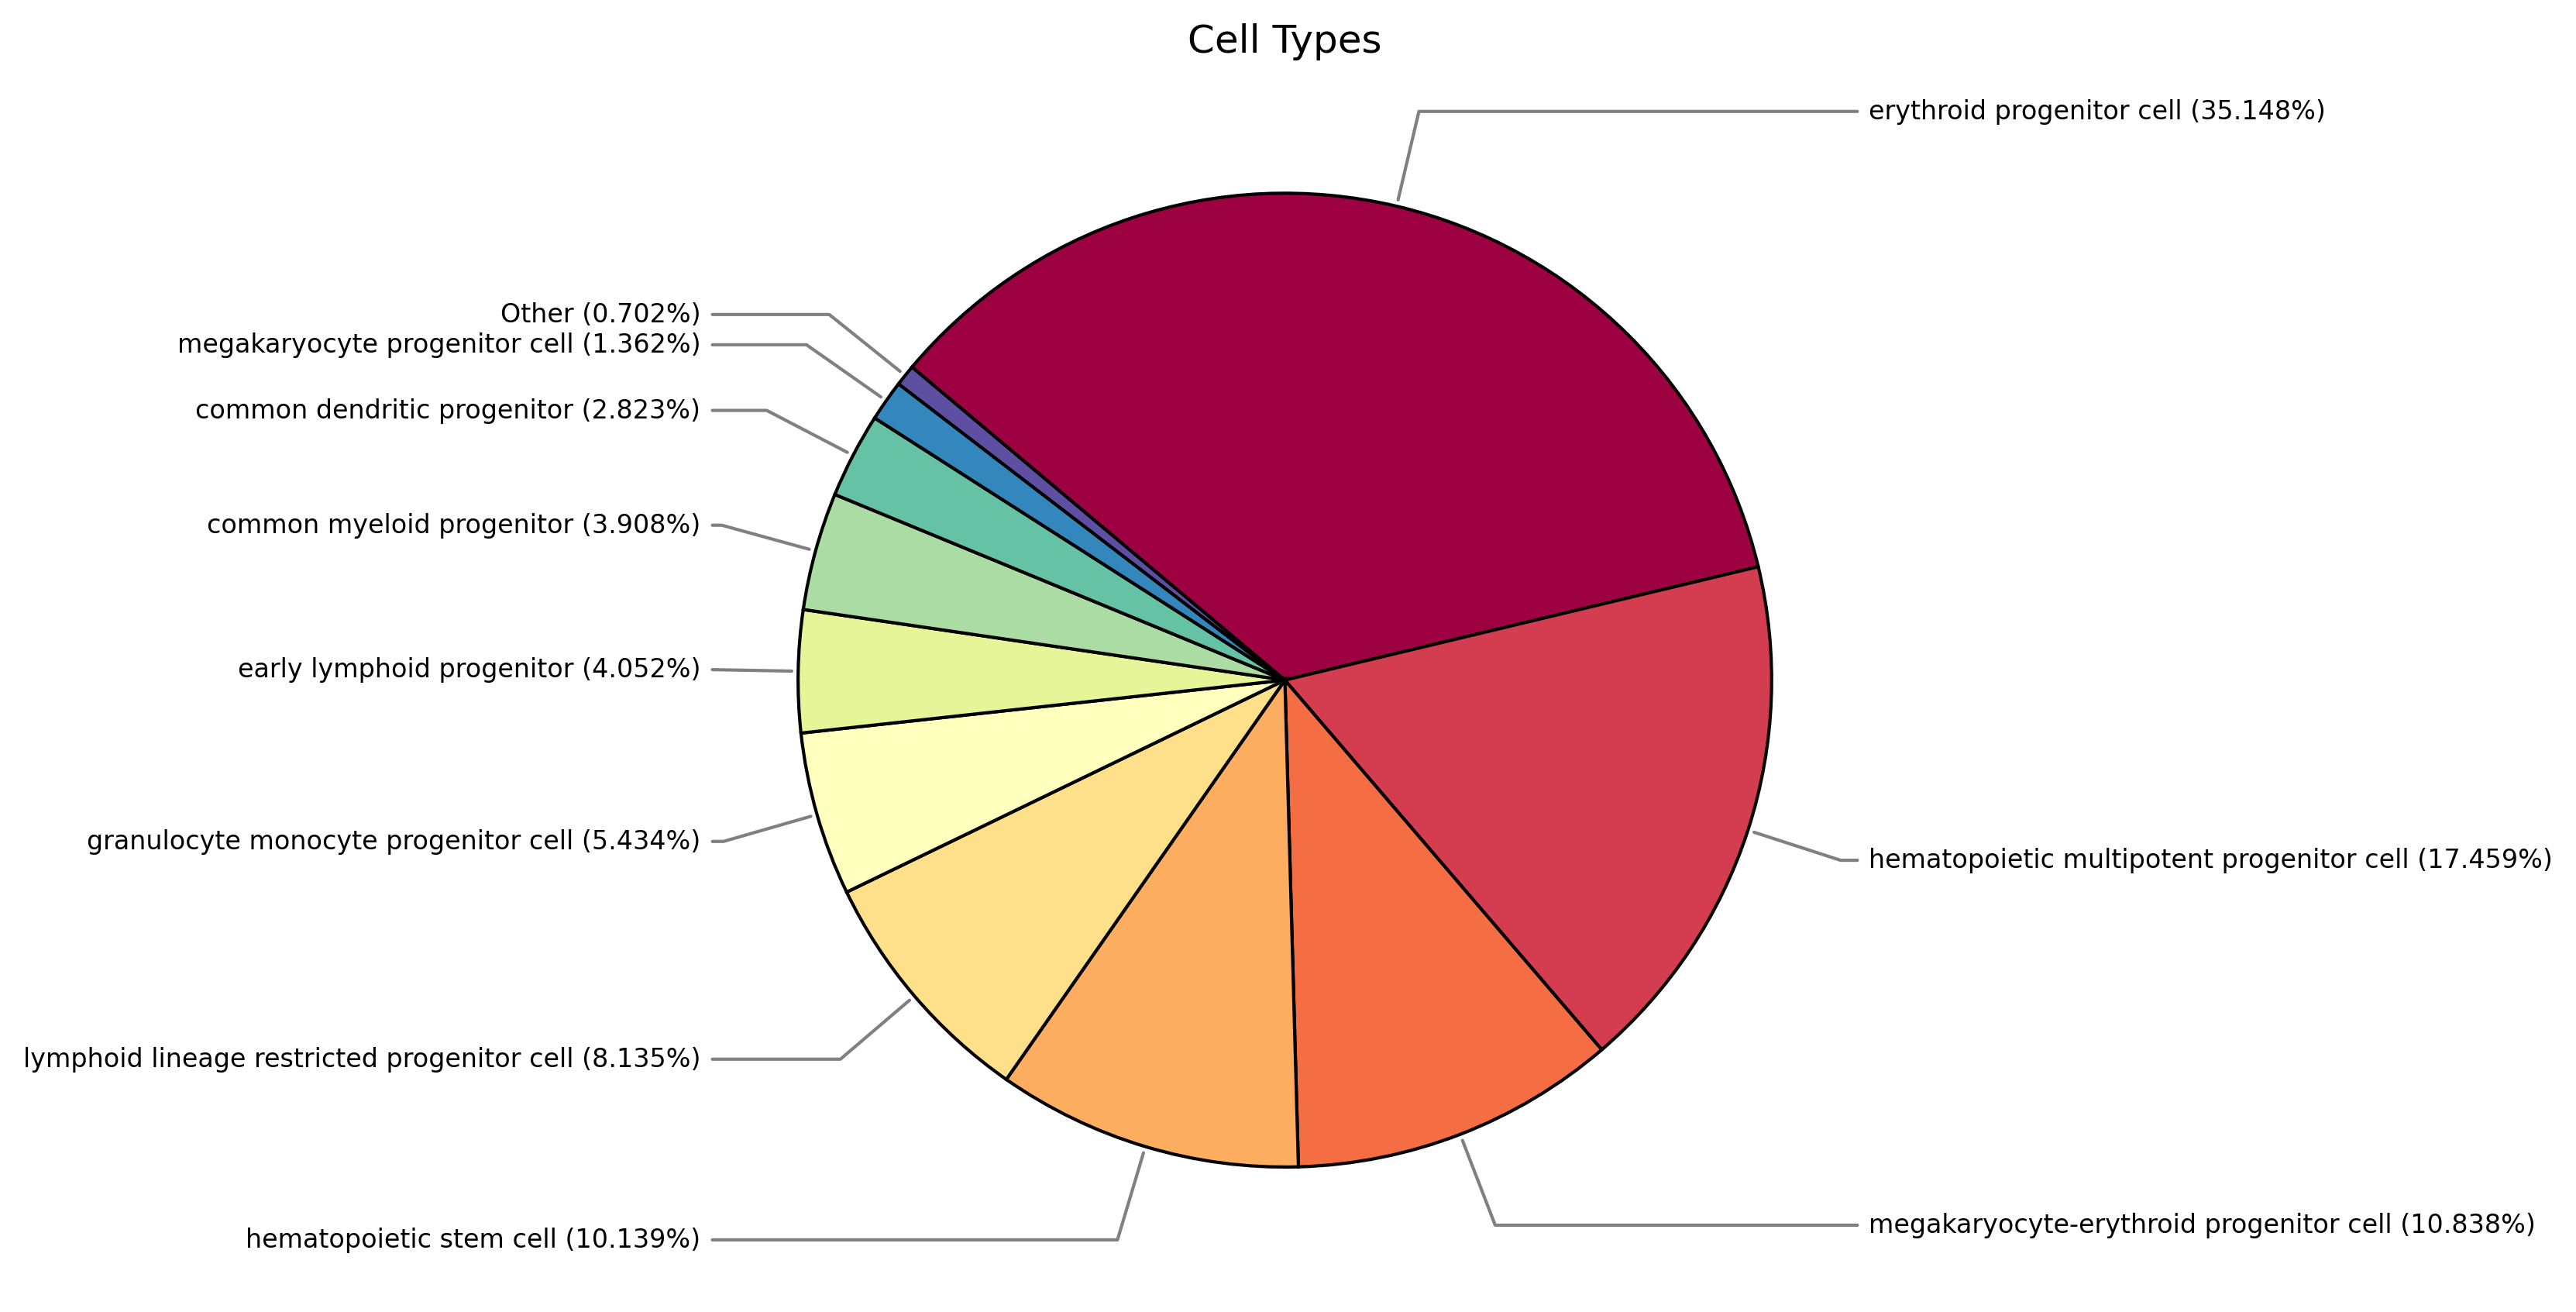

In [52]:
# Compute value counts
value_counts = pdf['cell_type_annotation'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.Spectral(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_title('Cell Types')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [57]:
print(value_counts_grouped.reset_index().to_latex(index=False))

\begin{tabular}{lr}
\toprule
cell_type_annotation & count \\
\midrule
erythroid progenitor cell & 23336 \\
hematopoietic multipotent progenitor cell & 11592 \\
megakaryocyte-erythroid progenitor cell & 7196 \\
hematopoietic stem cell & 6732 \\
lymphoid lineage restricted progenitor cell & 5401 \\
granulocyte monocyte progenitor cell & 3608 \\
early lymphoid progenitor & 2690 \\
common myeloid progenitor & 2595 \\
common dendritic progenitor & 1874 \\
megakaryocyte progenitor cell & 904 \\
Other & 466 \\
\bottomrule
\end{tabular}



# Tissues and Assays

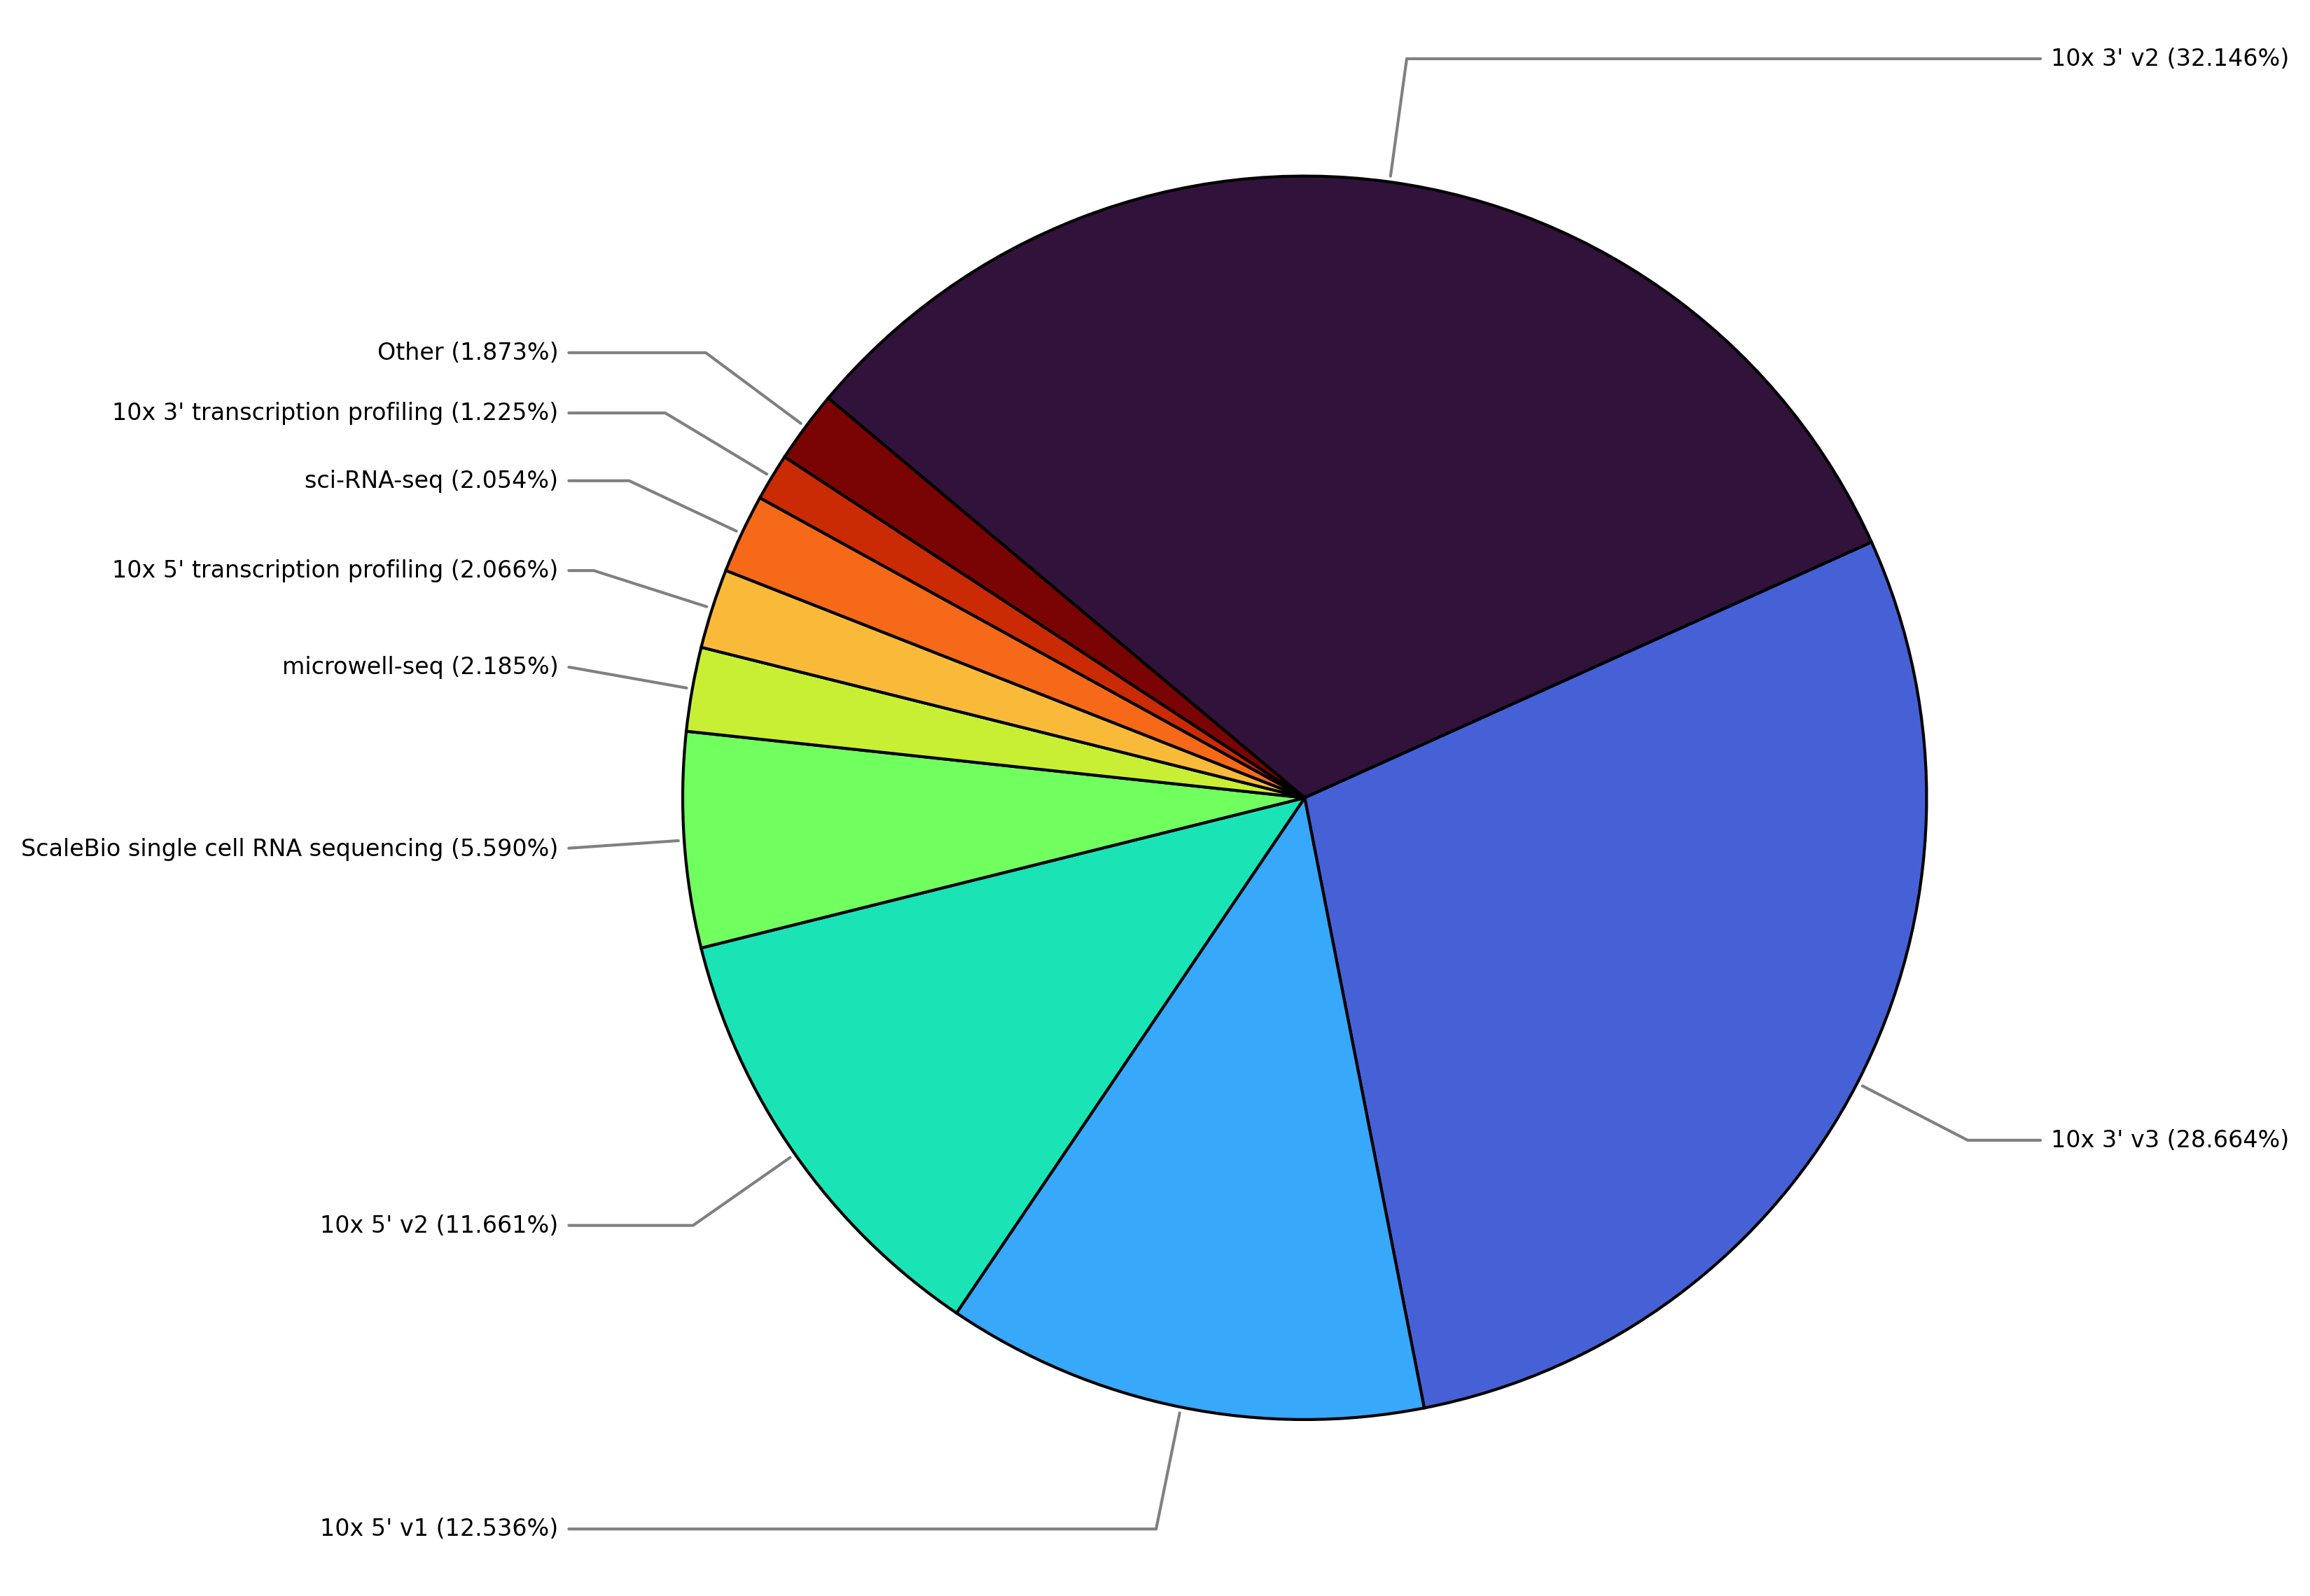

In [59]:
# Compute value counts
value_counts = df['assay'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.turbo(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

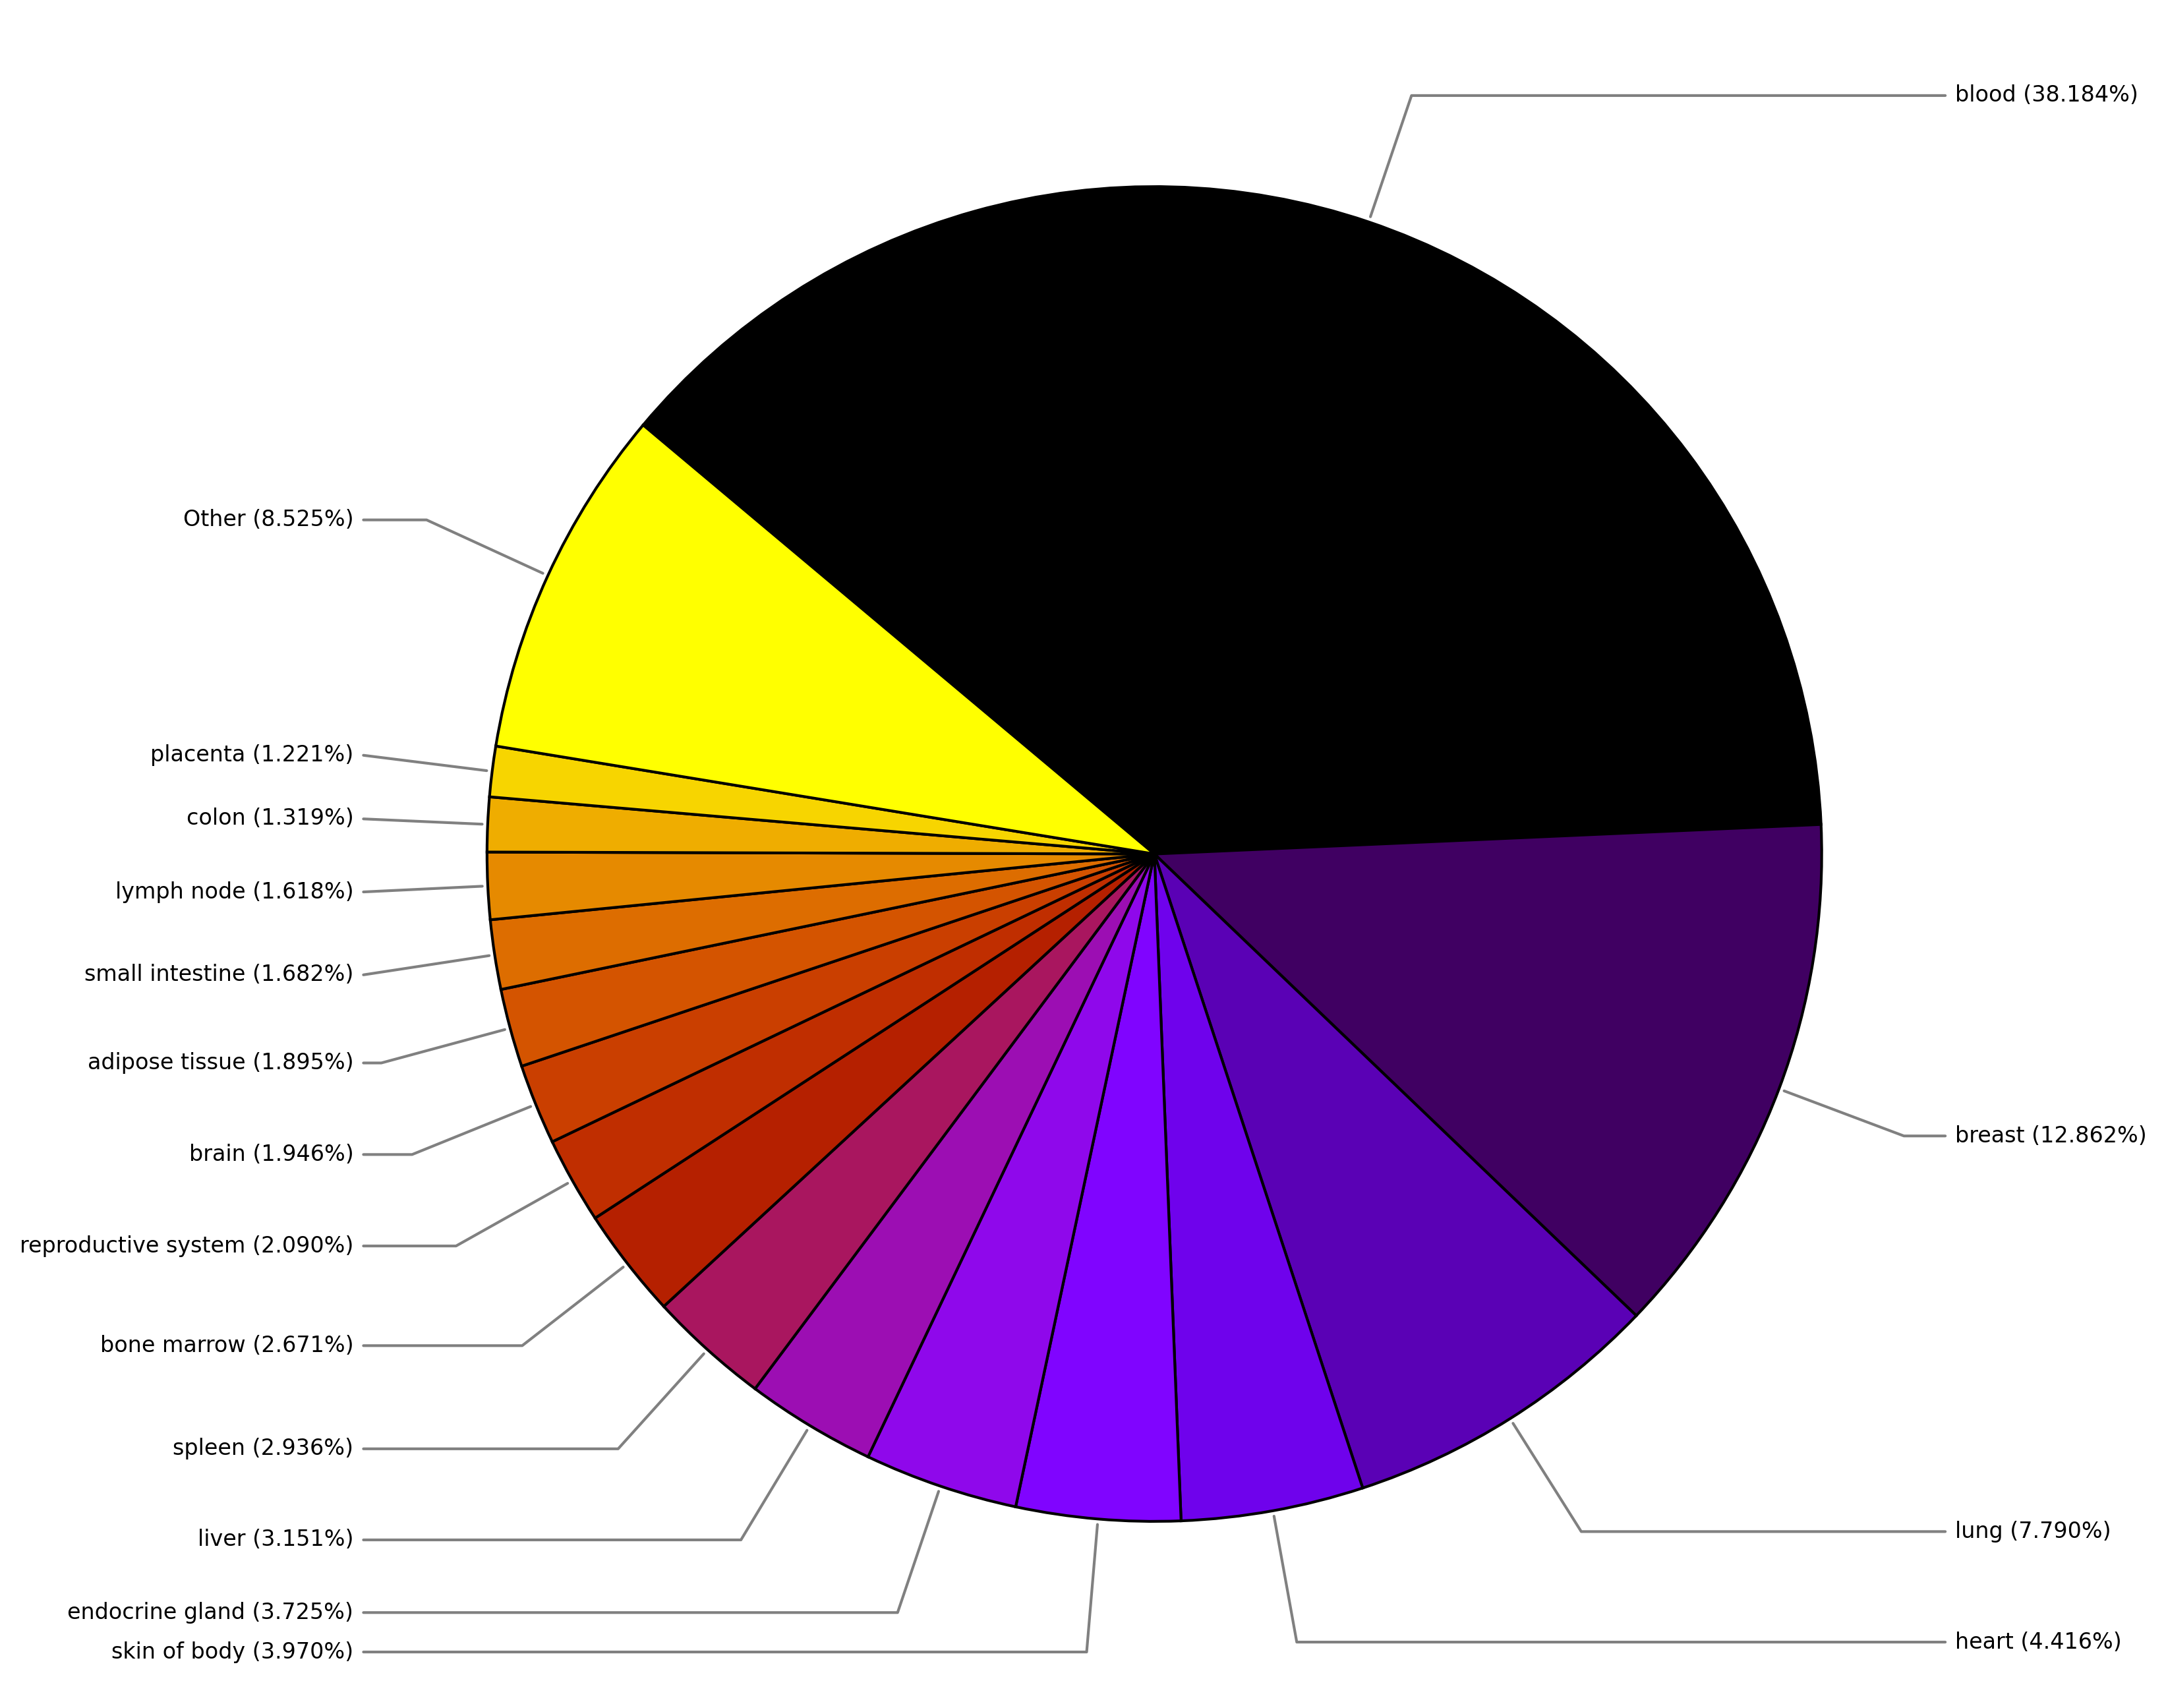

In [70]:
# Compute value counts
value_counts = df['tissue_general'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Colors
colors = plt.cm.gnuplot(np.linspace(0, 1, len(value_counts_grouped)))

size = 11
# Pie chart without labels
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    
    ax.annotate(
        # f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i]})",
        f"{value_counts_grouped.index[i]} ({value_counts_grouped.iloc[i] / total * 100:.3f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [71]:
df.columns

Index(['soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id',
       'cell_type', 'cell_type_ontology_term_id', 'development_stage',
       'development_stage_ontology_term_id', 'disease',
       'disease_ontology_term_id', 'donor_id', 'is_primary_data',
       'observation_joinid', 'self_reported_ethnicity',
       'self_reported_ethnicity_ontology_term_id', 'sex',
       'sex_ontology_term_id', 'suspension_type', 'tissue',
       'tissue_ontology_term_id', 'tissue_type', 'tissue_general',
       'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz',
       'raw_variance_nnz', 'n_measured_vars', 'basename',
       'cell_type_annotation', 'level_1_annotation'],
      dtype='object')

Text(0.5, 0, '')

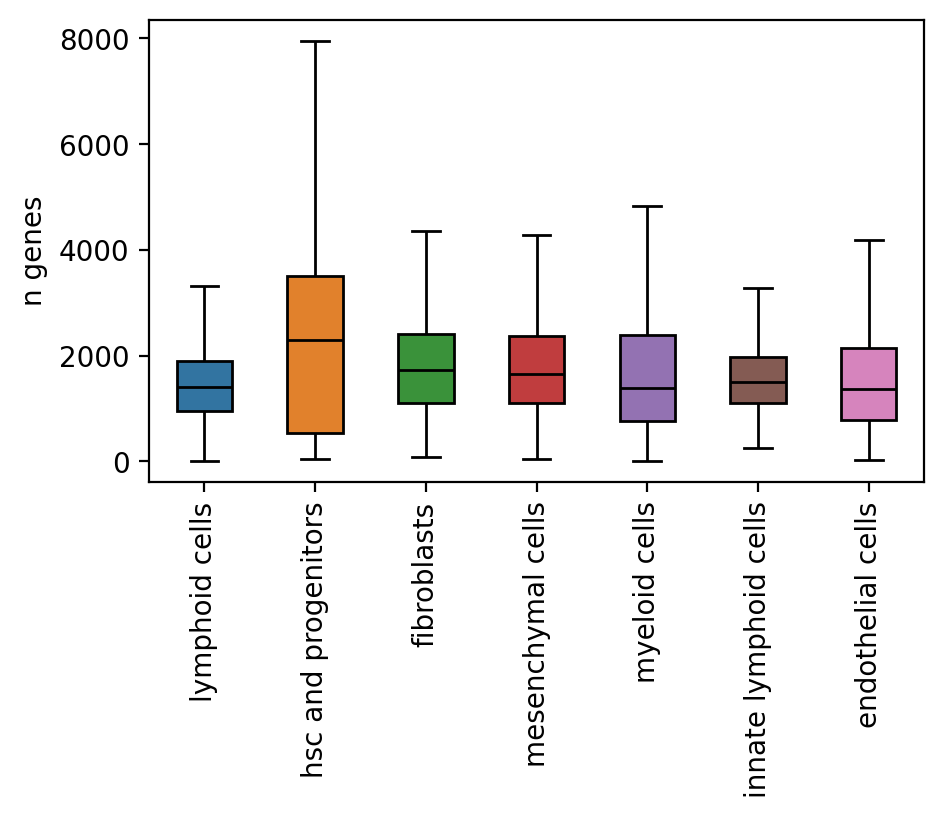

In [77]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.boxplot(
    data=df,
    x='basename',
    y='nnz',
    hue='basename',
    palette='tab10',
    width=0.5,
    showfliers=False,
    linecolor='k',
)

plt.gca().tick_params(axis='x', rotation=90)
plt.ylabel("n genes")
plt.xlabel("")

In [6]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)